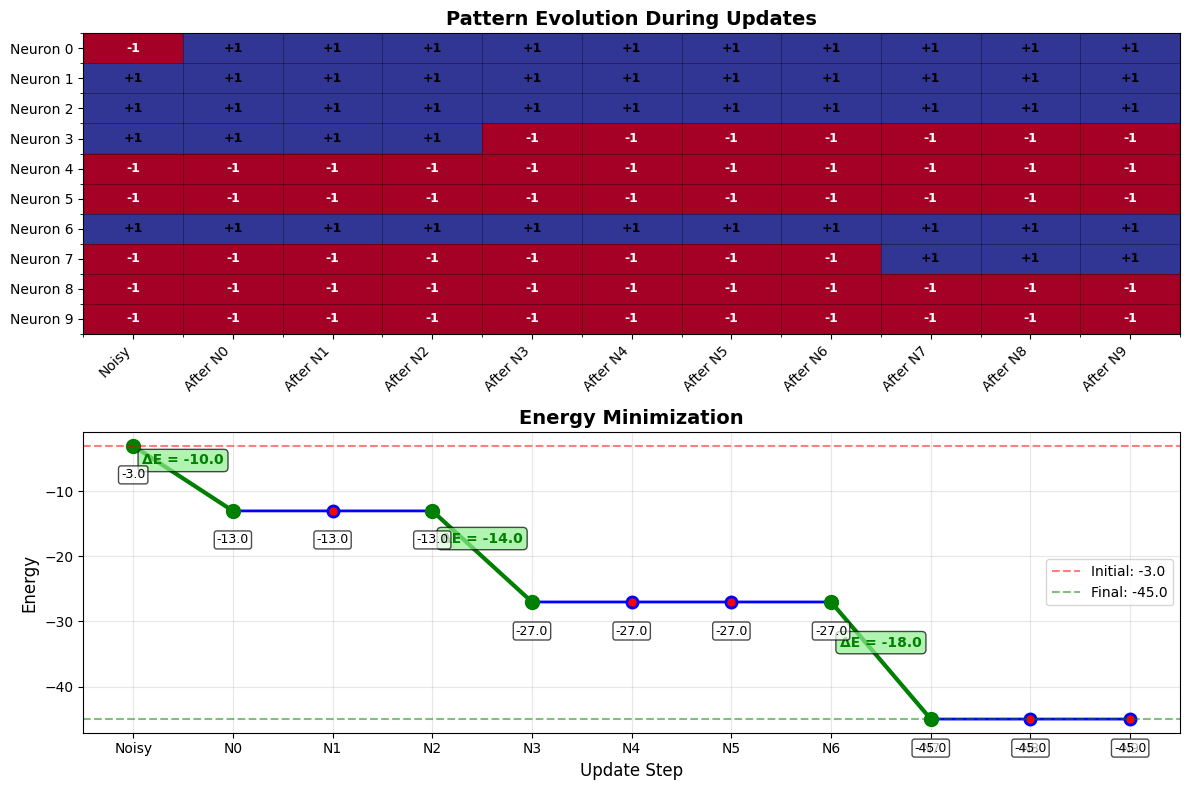

PATTERN RECOVERY SUMMARY
Target pattern:   [ 1  1  1 -1 -1 -1  1  1 -1 -1]
Noisy input:      [-1  1  1  1 -1 -1  1 -1 -1 -1]
Final state:      [ 1  1  1 -1 -1 -1  1  1 -1 -1]

Initial energy:   -3.00
Final energy:     -45.00
Energy reduction: 42.00

Pattern matches:
  Noisy input: 7/10 correct
  Final state: 10/10 correct


In [1]:
import numpy as np
import matplotlib.pyplot as plt

class HopfieldSimple:
    def __init__(self, n_neurons=10):
        self.n_neurons = n_neurons


    def train(self, pattern):
        """Store pattern using Hebbian learning"""
        pattern = pattern.reshape(-1, 1)
        self.weights = np.dot(pattern, pattern.T)
        np.fill_diagonal(self.weights, 0)

    def energy(self, state):
        """Calculate energy of a state"""
        return -0.5 * np.sum(self.weights * np.outer(state, state))

    def update(self, state, neuron):
        """Update single neuron"""
        net_input = np.sum(self.weights[neuron] * state)
        new_state = state.copy()
        new_state[neuron] = 1 if net_input >= 0 else -1
        return new_state

# Create pattern and network
pattern = np.array([1, 1, 1, -1, -1, -1, 1, 1, -1, -1])
noisy = pattern.copy()
noisy[[0, 3,7]] *= -1  # Flip 3 neurons

# Train network
net = HopfieldSimple(10)
net.train(pattern)

# Simulate updates
states = [noisy.copy()]
energies = [net.energy(noisy)]

# Update neurons
for i in range(10):
    new_state = net.update(states[-1], i)
    states.append(new_state)
    energies.append(net.energy(new_state))

# Create visualization
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8))

# Plot 1: Pattern Evolution
ax1.set_title('Pattern Evolution During Updates', fontsize=14, fontweight='bold')
cmap = plt.cm.RdYlBu

# Create grid for pattern visualization
pattern_grid = np.array(states).T  # 10 neurons x 11 steps

im = ax1.imshow(pattern_grid, cmap=cmap, aspect='auto',
                vmin=-1, vmax=1, interpolation='nearest')

# Add grid lines
ax1.set_xticks(np.arange(-0.5, 11, 1), minor=True)
ax1.set_yticks(np.arange(-0.5, 10, 1), minor=True)
ax1.grid(which='minor', color='black', linestyle='-', linewidth=0.5, alpha=0.5)

# Label steps
step_labels = ['Noisy'] + [f'After N{i}' for i in range(10)]
ax1.set_xticks(range(11))
ax1.set_xticklabels(step_labels, rotation=45, ha='right')

# Label neurons
ax1.set_yticks(range(10))
ax1.set_yticklabels([f'Neuron {i}' for i in range(10)])

# Add value annotations
for i in range(10):
    for j in range(11):
        value = pattern_grid[i, j]
        color = 'white' if value == -1 else 'black'
        ax1.text(j, i, f'{int(value):+d}', ha='center', va='center',
                color=color, fontweight='bold', fontsize=9)

# Plot 2: Energy Minimization
ax2.set_title('Energy Minimization', fontsize=14, fontweight='bold')
ax2.plot(range(11), energies, 'b-o', linewidth=2, markersize=8,
         markerfacecolor='red', markeredgewidth=2)

# Highlight when energy decreases
for i in range(1, 11):
    if energies[i] < energies[i-1]:
        ax2.plot([i-1, i], [energies[i-1], energies[i]], 'g-o',
                linewidth=3, markersize=10, markerfacecolor='green')
        ax2.annotate(f'ΔE = {energies[i]-energies[i-1]:.1f}',
                    xy=(i-0.5, (energies[i-1]+energies[i])/2),
                    xytext=(0, 10), textcoords='offset points',
                    ha='center', fontweight='bold', color='green',
                    bbox=dict(boxstyle='round,pad=0.3', facecolor='lightgreen', alpha=0.7))

# Add grid and labels
ax2.grid(True, alpha=0.3)
ax2.set_xlabel('Update Step', fontsize=12)
ax2.set_ylabel('Energy', fontsize=12)
ax2.set_xticks(range(11))
ax2.set_xticklabels(['Noisy'] + [f'N{i}' for i in range(10)])

# Add horizontal lines for initial and final energy
ax2.axhline(y=energies[0], color='red', linestyle='--', alpha=0.5, label=f'Initial: {energies[0]:.1f}')
ax2.axhline(y=energies[-1], color='green', linestyle='--', alpha=0.5, label=f'Final: {energies[-1]:.1f}')

# Add energy values on plot
for i, (x, y) in enumerate(zip(range(11), energies)):
    ax2.text(x, y-5, f'{y:.1f}', ha='center', fontsize=9,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.7))

ax2.legend(loc='best')

plt.tight_layout()
plt.show()

# Print simple statistics
print("="*60)
print("PATTERN RECOVERY SUMMARY")
print("="*60)
print(f"Target pattern:   {pattern}")
print(f"Noisy input:      {noisy}")
print(f"Final state:      {states[-1]}")
print()
print(f"Initial energy:   {energies[0]:.2f}")
print(f"Final energy:     {energies[-1]:.2f}")
print(f"Energy reduction: {energies[0] - energies[-1]:.2f}")
print()
print("Pattern matches:")
print(f"  Noisy input: {np.sum(noisy == pattern)}/10 correct")
print(f"  Final state: {np.sum(states[-1] == pattern)}/10 correct")